# **ESTUDO DE CASO: MÉTODOS DE PROJEÇÃO**
##### **Nome do(a) Aluno(a)**: TELMA TIEMI SHIMOZAKO
##### **Case**: *Potencial de Novos Clientes* <br> **Base de Dados**: *Potencial_Novos_Clientes.txt*
--------------

### **INSTALAÇÃO/CARREGAMENTO DE BIBLIOTECAS**

In [1]:
# Insira seus códigos em Python aqui (divida em várias células, se desejar)

In [2]:
#! pip install shap
#! pip install xgboost 
# ! pip install lightgbm 
#! pip install shap

In [3]:
import pandas as pd                                                                # Manipulação de dados
import numpy as np                                                                 # Realização de cálculos específicos
import matplotlib.pyplot as plt                                                    # Visualização de dados 
import seaborn as sns                                                              # Visualização de dados
import time                                                                        # Cálculo de tempo de execução
import math                                                                        # Funções matemáticas
from scipy.stats import randint, uniform, loguniform                               # Geração de valores aleatórios
from sklearn.compose import ColumnTransformer                                      # Transformação de colunas
from sklearn.preprocessing import StandardScaler, OneHotEncoder                    # Transformação de colunas
from sklearn.base import clone                                                     # Criação de cópias de modelos
from sklearn.model_selection import train_test_split, KFold, RandomizedSearchCV    # Validação simples e validação cruzada
from sklearn.metrics import r2_score, root_mean_squared_error                      # Métricas de avaliação de modelos
from sklearn.linear_model import Ridge, Lasso, ElasticNet, SGDRegressor            # Regressão linear com regularização
from sklearn.tree import DecisionTreeRegressor                                     # Árvore de regressão
from sklearn.ensemble import RandomForestRegressor                                 # Floresta aleatória
from sklearn.ensemble import AdaBoostRegressor, GradientBoostingRegressor          # Impulsionamento tradicional
from sklearn.ensemble import HistGradientBoostingRegressor                         # Impulsionamento com histogramas
from xgboost import XGBRegressor                                                   # Impulsionamento via XGBoost
from lightgbm import LGBMRegressor                                                 # Impulsionamento via LightGBM
from sklearn.inspection import permutation_importance                              # Importância de variáveis por permutação
import shap   
import statsmodels.api as sm                                                   # Regressão linear com statsmodels
from statsmodels.stats.outliers_influence import variance_inflation_factor      # Cálculo do VIF

C:\Users\telma\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### **LEITURA DA BASE DE DADOS**

In [4]:
# Insira seus códigos em Python aqui (divida em várias células, se desejar)

In [5]:
dados = pd.read_table("D:\\TELMA\\Documents\\FIA\\MBA\\Potencial_Novos_Clientes.txt",  # Substitua pelo nome da base de dados
                      sep="\t",                     # Ajuste o separador de colunas, se necessário
                      decimal=".",                  # Ajuste o separador de decimal, se necessário
                      header=0)

### **VISUALIZAÇÃO DA BASE DE DADOS**

In [6]:
dados.head(15)  # Exibe as primeiras 10 linhas do DataFrame

,COD_CARTAO,IDADE_CLIENTE,RENDA_MENSAL_CLIENTE,BEHAVIOUR_SCORE_CLIENTE,QTD_TRANSACOES_3M,QTD_ITENS_3M,VALOR_GASTO_3M,TICKET_MEDIO_3M,FLAG_ALTO_CUSTO_3M,SATISFACAO_CARTAO,VALOR_GASTO_PROX_12M
0,212394,22,1500,52,2,4,802,401.00,0,01_Muito_Satisfeito,226
1,279177,29,1800,94,5,5,1384,276.80,1,03_Neutro,2786
2,291430,36,1500,89,5,6,1610,322.00,1,Nao_Respondeu,3737
3,176612,43,1500,48,3,4,836,278.67,0,01_Muito_Satisfeito,1162
4,223092,28,12090,89,4,5,1318,329.50,0,Nao_Respondeu,2699
5,161386,18,1500,55,1,3,192,192.00,0,02_Satisfeito,0
6,219659,53,15330,89,4,8,1095,273.75,0,03_Neutro,3006
7,292045,57,1500,73,3,8,2105,701.67,0,03_Neutro,2984
8,138634,35,1500,60,2,1,640,320.00,0,02_Satisfeito,607
9,217273,34,1500,88,3,5,1879,626.33,0,Nao_Respondeu,2476


### **Dimensões da base de dados**

In [7]:
dados.shape

(2930, 11)

### **Tipos das colunas da base de dados**

In [8]:
dados.dtypes

COD_CARTAO                   int64
IDADE_CLIENTE                int64
RENDA_MENSAL_CLIENTE         int64
BEHAVIOUR_SCORE_CLIENTE      int64
QTD_TRANSACOES_3M            int64
QTD_ITENS_3M                 int64
VALOR_GASTO_3M               int64
TICKET_MEDIO_3M            float64
FLAG_ALTO_CUSTO_3M           int64
SATISFACAO_CARTAO           object
VALOR_GASTO_PROX_12M         int64
dtype: object

### **QUESTÃO 1**

#### 1. (1 ponto) Realize uma análise bivariada para examinar graficamente a existência de associação entre a variável resposta e cada uma das variáveis explicativas. Escolha os gráficos apropriados para cada situação. Interprete todos os gráficos gerados.

In [9]:
# Insira seus códigos em Python aqui (divida em várias células, se desejar)

*Tratamento de valores ausentes nas variáveis explicativas quantitativas, se houver*

In [10]:
# Verificando a quantidade de valores ausentes
# Não há valores ausentes.
dados.isna().sum()

COD_CARTAO                 0
IDADE_CLIENTE              0
RENDA_MENSAL_CLIENTE       0
BEHAVIOUR_SCORE_CLIENTE    0
QTD_TRANSACOES_3M          0
QTD_ITENS_3M               0
VALOR_GASTO_3M             0
TICKET_MEDIO_3M            0
FLAG_ALTO_CUSTO_3M         0
SATISFACAO_CARTAO          0
VALOR_GASTO_PROX_12M       0
dtype: int64

In [11]:
# Sugestão de tratamento de valores ausentes em uma variável explicativa quantitativa, por meio da criação de faixas
# dados['NOME_VARIAVEL'] = pd.to_numeric(dados['NOME_VARIAVEL'])
# dados['NOME_VARIAVEL_CAT'] = pd.qcut(dados['NOME_VARIAVEL'], q=10, duplicates='drop')
# dados['NOME_VARIAVEL_CAT'] = dados['NOME_VARIAVEL_CAT'].cat.add_categories('NA').fillna('NA')
# dados['NOME_VARIAVEL_CAT'].value_counts(dropna=False)

*Lista de nomes das variáveis explicativas, separando em quantitativas e qualitativas*

In [12]:
# Variáveis explicativas quantitativas (deixar vazio [] caso não haja nenhuma)
lista_X_quanti = ['IDADE_CLIENTE',
                  'RENDA_MENSAL_CLIENTE',
                  'BEHAVIOUR_SCORE_CLIENTE',
                  'QTD_TRANSACOES_3M',
                  'QTD_ITENS_3M',
                  'VALOR_GASTO_3M',
                  'TICKET_MEDIO_3M']

# Variáveis explicativas qualitativas (deixar vazio [] caso não haja nenhuma)
lista_X_quali = ['FLAG_ALTO_CUSTO_3M',
                 'SATISFACAO_CARTAO']

*Objetos para variável resposta (y) e explicativas (X)*

In [13]:
y = dados['VALOR_GASTO_PROX_12M']
X = dados[lista_X_quanti + lista_X_quali]

*Análise bivariada: gráficos de boxplot para variáveis explicativas qualitativas versus variável resposta*

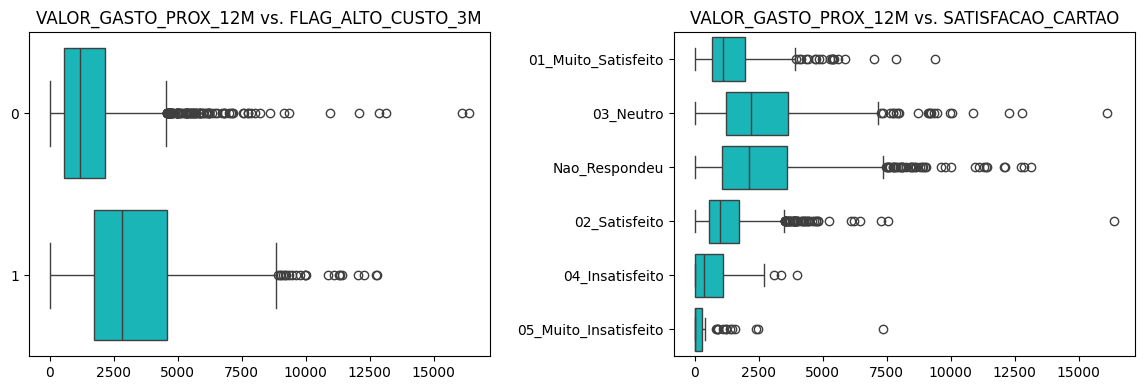

In [14]:
if lista_X_quali:
    n = len(lista_X_quali)
    ncols = 3
    nrows = math.ceil(n / ncols)
    fig, axes = plt.subplots(nrows=nrows,
                             ncols=ncols,
                             figsize=(6 * ncols, 4 * nrows))
    axes = axes.flatten()

    for i, var in enumerate(lista_X_quali):
        sns.boxplot(y=dados[var],
                    x=y,
                    ax=axes[i],
                    orient='h',
                    color='darkturquoise')
        axes[i].set_title(f'{y.name} vs. {var}')
        axes[i].tick_params(axis='x', rotation=0)
        axes[i].set_xlabel("")
        axes[i].set_ylabel("")

    for j in range(i+1, len(axes)):
        fig.delaxes(axes[j])

    fig.tight_layout(h_pad=2, w_pad=2)
    plt.show()

*Análise bivariada: gráficos de dispersão para variáveis explicativas quantitativas versus variável resposta*

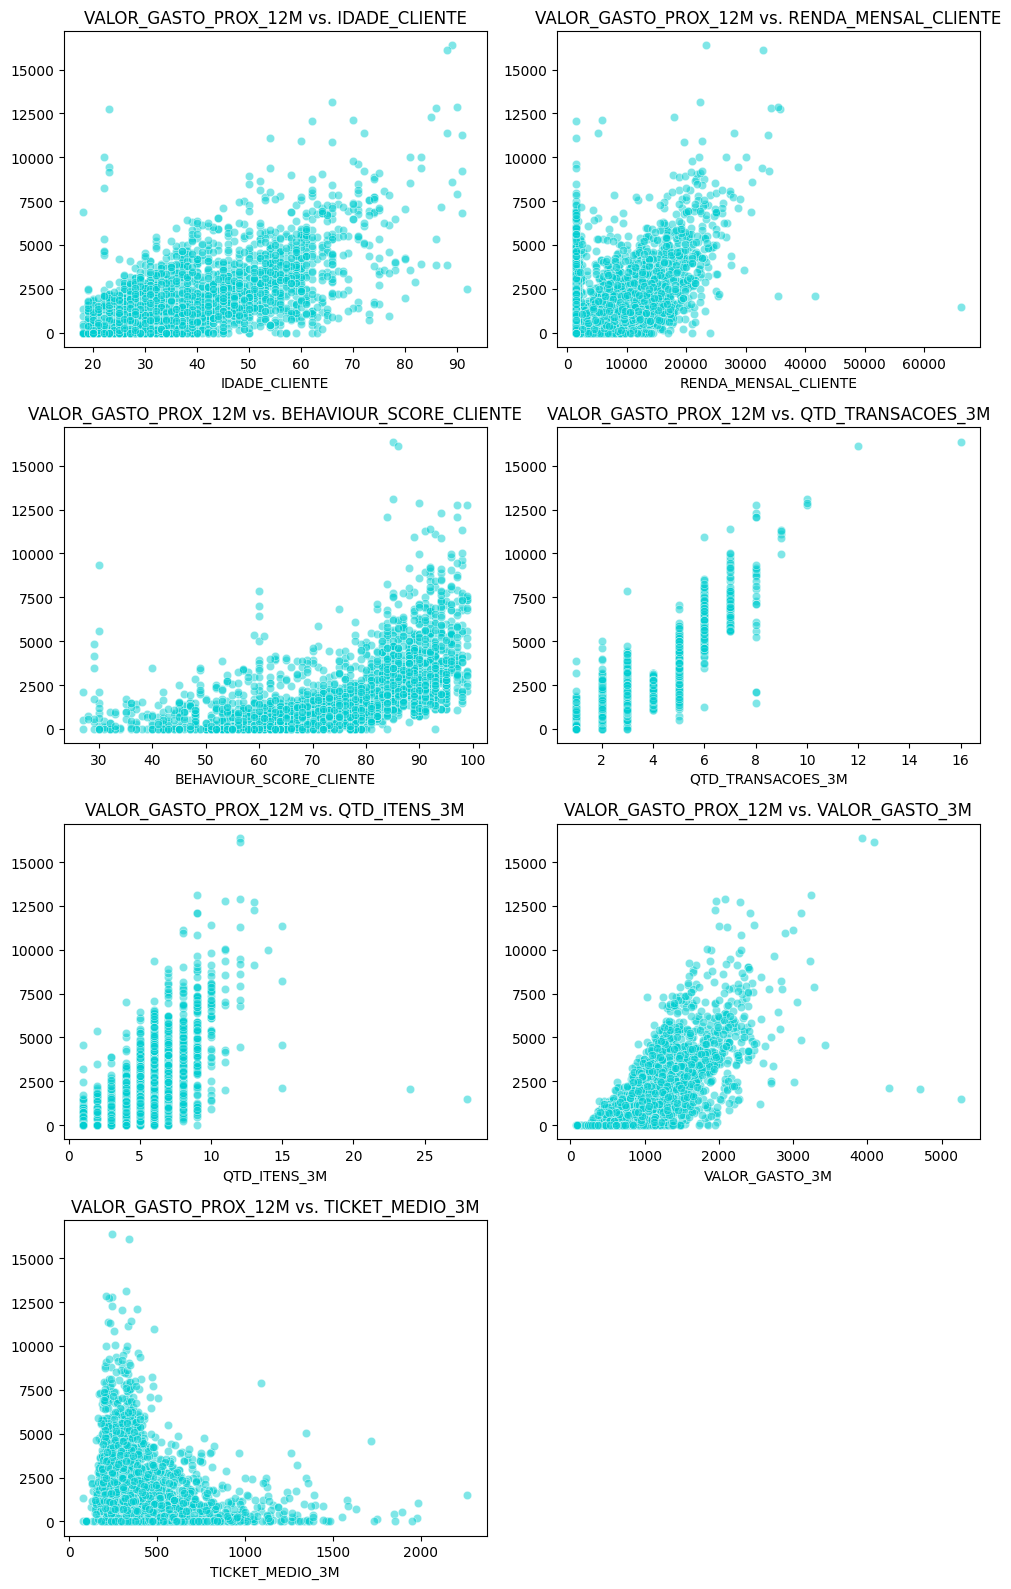

In [15]:
if lista_X_quanti:
    n = len(lista_X_quanti)
    ncols = 2
    nrows = math.ceil(n / ncols)
    fig, axes = plt.subplots(nrows=nrows,
                             ncols=ncols,
                             figsize=(5 * ncols, 4 * nrows))
    axes = axes.flatten()

    for i, var in enumerate(lista_X_quanti):
        sns.scatterplot(x=dados[var],
                        y=y,
                        ax=axes[i],
                        color='darkturquoise',
                        alpha=0.5)
        axes[i].set_title(f'{y.name} vs. {var}')
        axes[i].set_ylabel("")

    for j in range(i+1, len(axes)):
        fig.delaxes(axes[j])

    fig.tight_layout()
    plt.show()

Insira seu texto de conclusões aqui

Conclusões: No primeiro bloco de gráficos gerados (Gráficos de Boxplot), no gráfico VALOR_GASTO_PROX_12M vs FLAG_ALTO_CUSTO_3M, podemos verificar pela mediana dos gráficos que os clientes que realizaram compras em estabelecimentos de alto custo gastaram cerca de duas vezes mais do que os clientes que não realizaram compras em estabelecimentos de alto custo apesar de verificarmos alguns outliers que não compraram em estabelecimentos de alto custo mas gastaram consideravelmente mais do que os clientes que mais gastaram em estabelecimentos de alto custo.

Sobre o gráfico VALOR_GASTO_PROX_12M vs SATISFACAO_CARTAO, vemos que os clientes que mais gastaram são os clientes considerados NEUTROS e que não responderam às pesquisas. Podemos ver no gráfico de boxplot que as medianas para essas duas classificações estão bem próximas. Por outro lado, os clientes Muito Insatisfeitos, em média, foram os que menos gastaram, o que já era esperado.

Sobre o gráfico de dispersão, VALOR_GASTO_PROX_12M vs IDADE_CLIENTE, podemos ver que, na maioria das vezes, clientes mais jovens gastam menos. O valor gasto tende a aumentar com a idade do cliente, apesar de verificarmos algumas exceções de clientes na faixa dos 20 anos ou menos gastando muito mais que a maioria dos clientes da mesma faixa etária. O mesmo ocorrendo para clientes mais velhos gastando tanto quanto ou menos que clientes mais jovens.

Sobre o gráfico VALOR_GASTO_PROX_12M vs RENDA_MENSAL_CLIENTE, verificamos que o valor gasto tende a aumentar conforme aumenta a renda mensal do cliente. Podemos verificar também uma grande quantidade de clientes com renda ZERO e gastando valores consideravelmente altos. Isso talvez aconteça porque o cliente não informou a sua renda no momento do cadastro.

No gráfico VALOR_GASTO_PROX_12M vs BEHAVIOUR_SCORE_CLIENTE, vemos um comportamento de aumento exponencial do valor gasto conforme aumenta o behaviour score do cliente.

No gráfico, VALOR_GASTO_PROX_12M vs QTD_TRANSACOES_3M vemos que o valor gasto tende a aumentar conforme aumenta a quantidade de transações.

Sobre o gráfico VALOR_GASTO_PROX_12M vs QTD_ITENS_3M também vemos uma tendência de aumento do valor gasto conforme aumenta a quantidade de itens adquiridos apesar de alguns outliers que mostram a compra de mais de 20 itens por um valor abaixo de R$2500,00.

No gráfico VALOR_GASTO_PROX_12M vs VALOR_GASTO_3M, também vemos um aumento do valor gasto no próximos 12 meses conforme aumenta o valor gasto nos últimos 3 meses mostrando que os clientes tem a intenção de manter para os próximos 12 meses o ritmo de compras adquirido nos últimos 3 meses.

No gráfico VALOR_GASTO_PROX_12M vs TICKET_MEDIO_3M, vemos uma alta concentração de clientes com baixo ticket médio nos últimos 3 meses e baixo valor gasto nos próximos 12 meses, indicando que esses clientes compram baixos valores com certa frequência na loja. No entanto, vemos em menor concentração, clientes com alto valor gasto em 12 meses e baixo ticket médio nos últimos 3 meses, indicando que nos primeiros 3 meses o cliente fez poucas compras no cartão e passou a comprar mais após esses prazo. O contrário também é visto: clientes com alto ticket médio nos primeiros 3 meses e baixo valor gasto nos 12 meses sequintes, ou seja, o cliente adquiriu altos valores nos primeiros 3 meses e diminuiu o ritmo de compras nos 12 meses seguintes.

### **QUESTÃO 2**

#### 2. (1 ponto) Calcule os índices de correlação linear de Pearson para todos os pares de variáveis quantitativas presentes na base de dados. Responda as seguintes questões:

### (a) Quais as duas variáveis explicativas mais correlacionadas com a variável resposta?
### Para cada uma delas, o fato de as correlações serem altas é coerente do ponto de vista de negócio? Por quê? 
### (b) Quais as duas variáveis explicativas menos correlacionadas com a resposta? Para cada uma delas, o fato de as correlações serem baixas é coerente do ponto de vista de negócio? Por quê?
### (c) Quais as duas variáveis explicativas mais correlacionadas entre si? O que essa correlação indica do ponto de vista de negócio? 

In [16]:
# Insira seus códigos em Python aqui (divida em várias células, se desejar)

*Análise bivariada: matriz de correlações lineares de Pearson para variáveis explicativas quantitativas*

In [17]:
matriz_cor = (pd.concat([dados[lista_X_quanti], y], axis=1)).corr().round(3)
matriz_cor

,IDADE_CLIENTE,RENDA_MENSAL_CLIENTE,BEHAVIOUR_SCORE_CLIENTE,QTD_TRANSACOES_3M,QTD_ITENS_3M,VALOR_GASTO_3M,TICKET_MEDIO_3M,VALOR_GASTO_PROX_12M
IDADE_CLIENTE,1.000,0.386,0.325,0.518,0.720,0.470,-0.046,0.609
RENDA_MENSAL_CLIENTE,0.386,1.000,0.294,0.350,0.520,0.198,-0.205,0.437
BEHAVIOUR_SCORE_CLIENTE,0.325,0.294,1.000,0.601,0.424,0.217,-0.489,0.538
QTD_TRANSACOES_3M,0.518,0.350,0.601,1.000,0.583,0.638,-0.505,0.888
QTD_ITENS_3M,0.720,0.520,0.424,0.583,1.000,0.440,-0.214,0.622
VALOR_GASTO_3M,0.470,0.198,0.217,0.638,0.440,1.000,0.197,0.702
TICKET_MEDIO_3M,-0.046,-0.205,-0.489,-0.505,-0.214,0.197,1.000,-0.294
VALOR_GASTO_PROX_12M,0.609,0.437,0.538,0.888,0.622,0.702,-0.294,1.000


*Análise bivariada: gráfico de calor para representar a matriz de correlações*

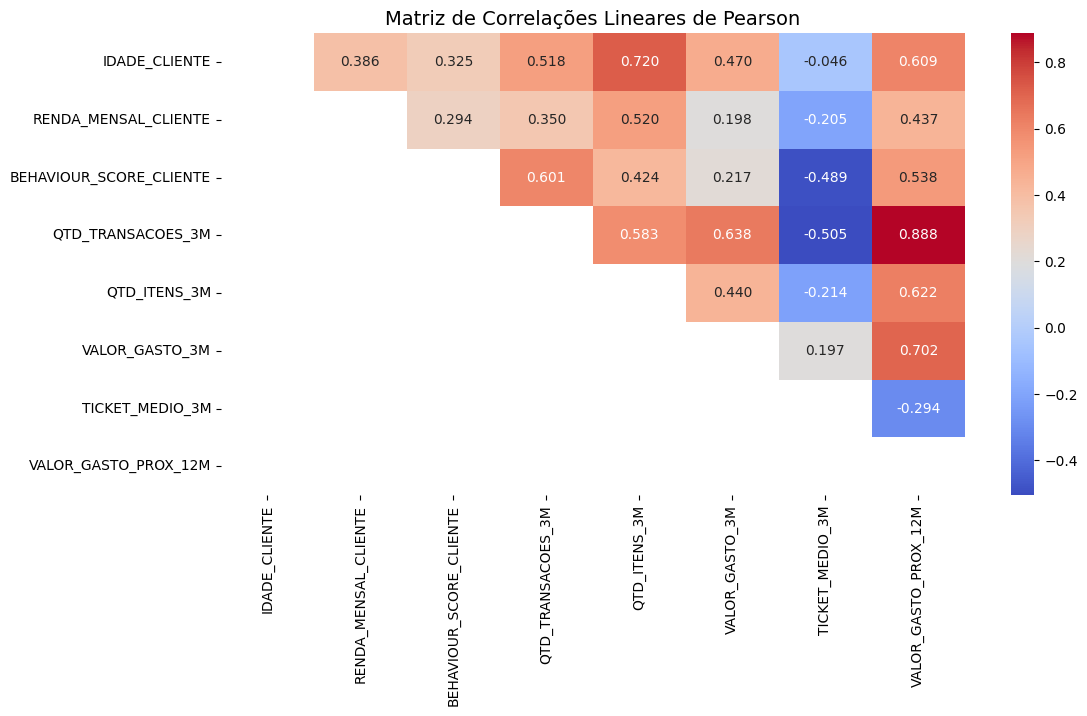

In [18]:
mask = np.tril(np.ones(matriz_cor.shape, dtype=bool))

plt.figure(figsize=(12, 6))
sns.heatmap(matriz_cor, mask=mask, annot=True, fmt=".3f", cmap="coolwarm")
plt.title("Matriz de Correlações Lineares de Pearson", fontsize=14)
plt.show()

Insira seu texto de conclusões aqui

Conclusões:
a) As duas variáveis explicativas mais correlacionadas com a variável resposta são QTD_TRANSACOES_3M (0,888) e VALOR_GASTO_3M (0,702). Do ponto de vista de negócio, é coerente que essas duas variáveis tenham alta correlação com a variável resposta pois é esperado que um cliente com alta quantidade de transações e valor gasto nos primeiros 3 meses mantenham esses mesmo nível de transações e valores gastos nos 12 meses subsequentes.

b) As variáveis explicativas menos correlacionadas com a variável
resposta são TICKET_MEDIO_3M (-0,294) e RENDA_MENSAL_CLIENTE (0,437). Do ponto de vista de negócio, a baixa correlação do TICKET_MEDIO_3M parece estar coerente do ponto de vista de negócio pois o ticket médio do cliente pode ser baixo porém sua quantidade de transações pode ser alta. Quanto à variável RENDA_MENSAL_CLIENTE, do ponto de vista do negócio, a baixa correlação com a variável resposta não parece estar coerente uma vez que para que o cliente tenha um alto valor gasto, à princípio, ele precisa ter uma renda também alta.

c) As duas variáveis explicativas mais correlacionadas entre si são IDADE_CLIENTE e QTD_ITENS_3M (0,720). Do ponto de vista de negócio, isso significa que quanto mais idade o cliente tem, mais itens ele comprou nos primeiros 3 meses.

### **QUESTÃO 3**

#### 3. (1 ponto) Crie dummies para as variáveis qualitativas e construa um modelo de regressão linear múltipla, considerando nível de significância de 3% e seleção manual de variáveis via stepwise backward. Neste momento, não avalie colinearidade. Interprete os coeficientes estimados de cada uma das variáveis que se mostrarem estatisticamente significativas, bem como o intercepto.

In [19]:
# Insira seus códigos em Python aqui (divida em várias células, se desejar)

*Definição da função de pré-processamento: Codificação one-hot para variáveis qualitativas*

In [20]:
preprocessador = ColumnTransformer(transformers=[
    ("quali", OneHotEncoder(sparse_output=False, drop="first", handle_unknown='ignore'), lista_X_quali)
],
    remainder='passthrough'
)

*Criação e aplicação do pré-processamento*

In [21]:
X_tratada = preprocessador.fit_transform(X)

if lista_X_quali:
    nomes_quali = list(preprocessador.named_transformers_['quali'].get_feature_names_out(lista_X_quali))
else:
    nomes_quali = []
nomes_variaveis = nomes_quali + list(lista_X_quanti)

In [22]:
X_tratada = pd.DataFrame(X_tratada, columns=nomes_variaveis)
X_tratada.head()

,FLAG_ALTO_CUSTO_3M_1,SATISFACAO_CARTAO_02_Satisfeito,SATISFACAO_CARTAO_03_Neutro,SATISFACAO_CARTAO_04_Insatisfeito,SATISFACAO_CARTAO_05_Muito_Insatisfeito,SATISFACAO_CARTAO_Nao_Respondeu,IDADE_CLIENTE,RENDA_MENSAL_CLIENTE,BEHAVIOUR_SCORE_CLIENTE,QTD_TRANSACOES_3M,QTD_ITENS_3M,VALOR_GASTO_3M,TICKET_MEDIO_3M
0,0.0,0.0,0.0,0.0,0.0,0.0,22.0,1500.0,52.0,2.0,4.0,802.0,401.00
1,1.0,0.0,1.0,0.0,0.0,0.0,29.0,1800.0,94.0,5.0,5.0,1384.0,276.80
2,1.0,0.0,0.0,0.0,0.0,1.0,36.0,1500.0,89.0,5.0,6.0,1610.0,322.00
3,0.0,0.0,0.0,0.0,0.0,0.0,43.0,1500.0,48.0,3.0,4.0,836.0,278.67
4,0.0,0.0,0.0,0.0,0.0,1.0,28.0,12090.0,89.0,4.0,5.0,1318.0,329.50


### **Etapa 3: Construção do modelo de regressão linear**

*Ajuste do modelo 1*

In [23]:
modelo_1 = sm.OLS(y, sm.add_constant(X_tratada)).fit()
print(modelo_1.summary(alpha=0.03))

                             OLS Regression Results                             
Dep. Variable:     VALOR_GASTO_PROX_12M   R-squared:                       0.857
Model:                              OLS   Adj. R-squared:                  0.857
Method:                   Least Squares   F-statistic:                     1349.
Date:                  Mon, 04 Aug 2025   Prob (F-statistic):               0.00
Time:                          20:54:45   Log-Likelihood:                -23499.
No. Observations:                  2930   AIC:                         4.703e+04
Df Residuals:                      2916   BIC:                         4.711e+04
Df Model:                            13                                         
Covariance Type:              nonrobust                                         
                                              coef    std err          t      P>|t|      [0.015      0.985]
----------------------------------------------------------------------------------

*Ajuste do modelo 2*

In [24]:
# Excluindo a variável 'SATISFACAO_CARTAO_02_Satisfeito' por ter nível de sgnificancia maior que 3%
X_tratada = X_tratada.drop(['SATISFACAO_CARTAO_02_Satisfeito'], axis=1)

In [25]:
modelo_2 = sm.OLS(y, sm.add_constant(X_tratada)).fit()
print(modelo_2.summary(alpha=0.03))

                             OLS Regression Results                             
Dep. Variable:     VALOR_GASTO_PROX_12M   R-squared:                       0.857
Model:                              OLS   Adj. R-squared:                  0.857
Method:                   Least Squares   F-statistic:                     1460.
Date:                  Mon, 04 Aug 2025   Prob (F-statistic):               0.00
Time:                          20:54:45   Log-Likelihood:                -23499.
No. Observations:                  2930   AIC:                         4.702e+04
Df Residuals:                      2917   BIC:                         4.710e+04
Df Model:                            12                                         
Covariance Type:              nonrobust                                         
                                              coef    std err          t      P>|t|      [0.015      0.985]
----------------------------------------------------------------------------------

*Ajuste do modelo 3*

In [26]:
# Excluindo a variável 'QTD_ITENS_3M' por ter nível de sgnificancia maior que 3%
X_tratada_1 = X_tratada.drop(['QTD_ITENS_3M'], axis=1)

In [27]:
X_tratada_1.dtypes

FLAG_ALTO_CUSTO_3M_1                       float64
SATISFACAO_CARTAO_03_Neutro                float64
SATISFACAO_CARTAO_04_Insatisfeito          float64
SATISFACAO_CARTAO_05_Muito_Insatisfeito    float64
SATISFACAO_CARTAO_Nao_Respondeu            float64
IDADE_CLIENTE                              float64
RENDA_MENSAL_CLIENTE                       float64
BEHAVIOUR_SCORE_CLIENTE                    float64
QTD_TRANSACOES_3M                          float64
VALOR_GASTO_3M                             float64
TICKET_MEDIO_3M                            float64
dtype: object

In [28]:
# Sem QTD_ITENS_3M
modelo_3 = sm.OLS(y, sm.add_constant(X_tratada_1)).fit()
print(modelo_3.summary(alpha=0.03))

                             OLS Regression Results                             
Dep. Variable:     VALOR_GASTO_PROX_12M   R-squared:                       0.857
Model:                              OLS   Adj. R-squared:                  0.857
Method:                   Least Squares   F-statistic:                     1593.
Date:                  Mon, 04 Aug 2025   Prob (F-statistic):               0.00
Time:                          20:54:45   Log-Likelihood:                -23500.
No. Observations:                  2930   AIC:                         4.702e+04
Df Residuals:                      2918   BIC:                         4.710e+04
Df Model:                            11                                         
Covariance Type:              nonrobust                                         
                                              coef    std err          t      P>|t|      [0.015      0.985]
----------------------------------------------------------------------------------

*Ajuste do modelo 4*

In [29]:
# Excluindo a variável 'SATISFACAO_CARTAO_04_Insatisfeito' por ter nível de sgnificancia maior que 3%
X_tratada_2 = X_tratada_1.drop(['SATISFACAO_CARTAO_04_Insatisfeito'], axis=1)

In [30]:
X_tratada_2.dtypes

FLAG_ALTO_CUSTO_3M_1                       float64
SATISFACAO_CARTAO_03_Neutro                float64
SATISFACAO_CARTAO_05_Muito_Insatisfeito    float64
SATISFACAO_CARTAO_Nao_Respondeu            float64
IDADE_CLIENTE                              float64
RENDA_MENSAL_CLIENTE                       float64
BEHAVIOUR_SCORE_CLIENTE                    float64
QTD_TRANSACOES_3M                          float64
VALOR_GASTO_3M                             float64
TICKET_MEDIO_3M                            float64
dtype: object

In [31]:
modelo_4 = sm.OLS(y, sm.add_constant(X_tratada_2)).fit()
print(modelo_4.summary())

                             OLS Regression Results                             
Dep. Variable:     VALOR_GASTO_PROX_12M   R-squared:                       0.857
Model:                              OLS   Adj. R-squared:                  0.857
Method:                   Least Squares   F-statistic:                     1751.
Date:                  Mon, 04 Aug 2025   Prob (F-statistic):               0.00
Time:                          20:54:45   Log-Likelihood:                -23502.
No. Observations:                  2930   AIC:                         4.703e+04
Df Residuals:                      2919   BIC:                         4.709e+04
Df Model:                            10                                         
Covariance Type:              nonrobust                                         
                                              coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------

### Insira seu texto de conclusões aqui

Conclusões:

Variáveis:
FLAG_ALTO_CUSTO_3M_1 - Quando o cliente realiza compras em estabelecimentos de alto custo, o valor gasto por ele em 12 meses aumenta em R$247,37 em comparação com clientes que não compraram em estabelecimentos de alto custo.

SATISFACAO_CARTAO_03 - Quando o nível de satisfação do cliente nos primeiros 3 meses é NEUTRO, o valor gasto por ele em 12 meses diminui em R$106,98 em comparação com clientes com nível de satisfação MUITO SATISFEITO. Quando o nível de satisfação do cliente nos primeiros 3 meses é MUITO INSATISFEITO, o valor gasto por ele em 12 meses diminui em R$225,52 em comparação com clientes com nível de satisfação MUITO SATISFEITO. Quando o cliente não responde à pesquisa de satisfação nos primeiros 3 meses, o valor gasto por ele em 12 meses diminui em R$125,49 em comparação com clientes com nível de satisfação MUITO SATISFEITO.

IDADE_CLIENTE - A cada ano de idade do cliente representa um aumento de R$15,92 no valor gasto por ele nos 12 meses seguintes.

RENDA_MENSAL_CLIENTE - Cada real declarado como renda mensal do cliente faz com que o valor gasto por ele nos 12 meses seguintes em compras aumente em R$0,0363.

BEHAVIOUR_SCORE_CLIENTE - Cada ponto referente ao Behaviour Score representa um aumento de R$6,76 no valor gasto pelo cliente em 12 meses de compras.

QTD_TRANSACOES_3M - Cada transação realizada pelo cliente nos primeiros 3 meses, aumenta o valor gasto por ele nos 12 meses seguintes em R$795,98.

VALOR_GASTO_3M - Cada real gasto nos primeiros 3 meses representa um aumento de de R$0,59 no valor gasto pelo cliente nos 12 meses seguintes.

TICKET_MEDIO_3M - Cada real do ticket médio calculado nos primeiros 3 meses representa um aumento de R$0,75 no valor gasto pelo cliente nos 12 meses seguintes.

intercepto (-2860,3690) - Representa o valor do gasto nos 12 meses seguintes todas as outras variáveis estejam "zeradas", o que nunca aconteceria pois estamos considerando entre outras variáveis renda mensal, idade e behaviour score, que nunca serão iguais a zero. Então, esse valor negativo representa um ajuste de escala, o valor que a variável resposta assumiria caso todas as variáveis explicativas sejam iguais a ZERO.

### **QUESTÃO 4**

4. (1 ponto) Por meio de índices VIF, avalie se existem indícios de colinearidade no modelo obtido no item anterior. Comente os resultados. Observação: Não realize novos ajustes de modelo, mesmo que haja colinearidade.

In [32]:
# Insira seus códigos em Python aqui (divida em várias células, se desejar)

*Avaliação de colinearidade*

In [33]:
modelo = modelo_4    # Digite o nome do objeto do modelo que deseja avaliar
vif = pd.DataFrame({
    "Variável": modelo.model.exog_names,
    "VIF": [variance_inflation_factor(modelo.model.exog, i) for i in range(modelo.model.exog.shape[1])]
})

print(vif)

                                   Variável        VIF
0                                     const  65.612346
1                      FLAG_ALTO_CUSTO_3M_1   1.442055
2               SATISFACAO_CARTAO_03_Neutro   1.568081
3   SATISFACAO_CARTAO_05_Muito_Insatisfeito   1.084742
4           SATISFACAO_CARTAO_Nao_Respondeu   1.707618
5                             IDADE_CLIENTE   1.633674
6                      RENDA_MENSAL_CLIENTE   1.288147
7                   BEHAVIOUR_SCORE_CLIENTE   2.375379
8                         QTD_TRANSACOES_3M   7.655327
9                            VALOR_GASTO_3M   4.610813
10                          TICKET_MEDIO_3M   3.920868


### Insira seu texto de conclusões aqui

Conclusões:
Sim. Existem indícios de colinearidade principalmente entre as variáveis explicativas BEHAVIOUR_SCORE_CLIENTE, QTD_TRANSACOES_3M, VALOR_GASTO_3M, TICKET_MEDIO_3M. Podemos ver que essas 4 variáveis tem relação entre si uma vez que se o cliente gastou altos valores nos últimos 3 meses, ele terá um alto behaviour score. Consequentemente, também terá ou um alto ticket médio ou alta quantidade de transações realizadas nos últimos 3 meses ou os dois.

### **QUESTÃO 5**

5. (1 ponto) Elabore gráficos de resíduos do modelo e calcule as distâncias de Cook. Os resíduos atendem às premissas de normalidade e homocedasticidade? Além disso,existem pontos influentes?

In [34]:
# Insira seus códigos em Python aqui (divida em várias células, se desejar)

*Coeficiente de determinação ajustado (R²)*

In [35]:
modelo_4.rsquared_adj   # Altere o nome do objeto do modelo

np.float64(0.856593725830535)

*Valores preditos pelo modelo (y^)*

In [36]:
y_hat = modelo_4.predict(sm.add_constant(X_tratada_2))   # Altere o nome do objeto do modelo

*Erro absoluto médio (MAE)*

In [37]:
np.mean(np.abs(y - y_hat))

np.float64(498.9937919471634)

*Erro absoluto percentual médio (MAPE)*

In [38]:
np.mean(np.abs((y - y_hat) / y))

np.float64(inf)

*Erro quadrático médio em raiz (RMSE)*

In [39]:
np.sqrt(np.mean((y - y_hat)**2))

np.float64(736.6725217312838)

*Resíduos do modelo (e)*

In [40]:
resid = modelo_4.resid   # Altere o nome do objeto do modelo

*Histograma dos resíduos*

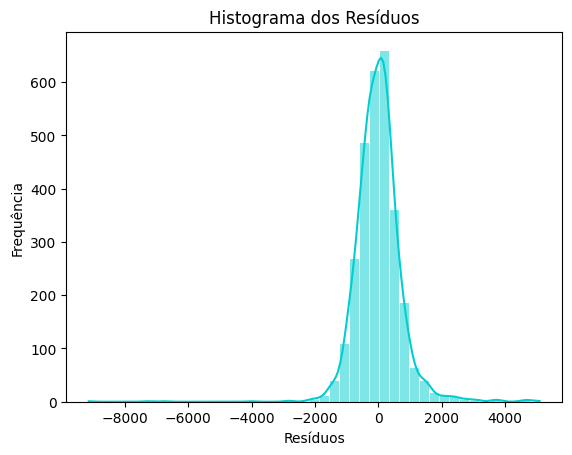

In [41]:
sns.histplot(resid,
             bins=45,    # Altere a quantidade de bins conforme necessário
             color="darkturquoise",
             edgecolor="white",
             kde=True)
plt.title("Histograma dos Resíduos")
plt.xlabel("Resíduos")
plt.ylabel("Frequência")
plt.show()

*Q-Q plot dos resíduos*

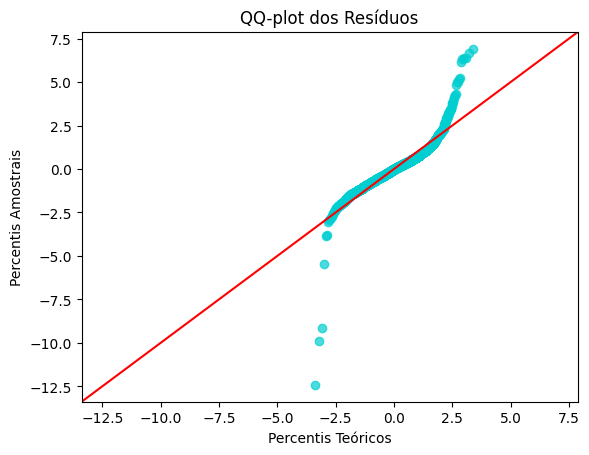

In [42]:
sm.qqplot(resid,
          line='45',
          fit=True,
          markerfacecolor='darkturquoise',
          markeredgecolor='darkturquoise',
          alpha=0.7)
plt.title("QQ-plot dos Resíduos")
plt.xlabel("Percentis Teóricos")
plt.ylabel("Percentis Amostrais")
plt.show()

*Gráfico de resíduos vs. valores preditos*

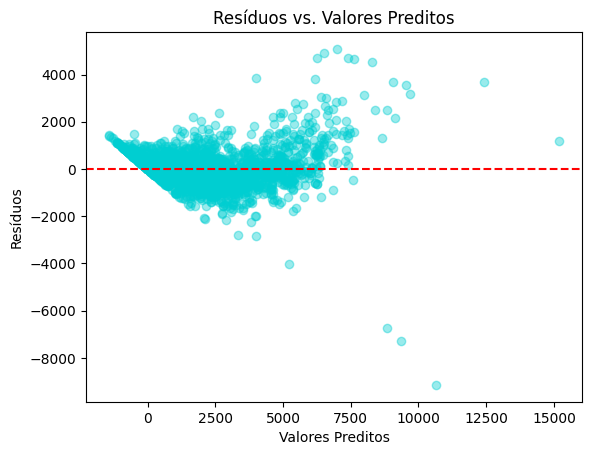

In [43]:
plt.scatter(y_hat,
            resid,
            color="darkturquoise",
            alpha=0.4)
plt.axhline(0, color='red', linestyle='--')
plt.title("Resíduos vs. Valores Preditos")
plt.xlabel("Valores Preditos")
plt.ylabel("Resíduos")
plt.show()

*Gráfico de valores observados vs. valores preditos da resposta*

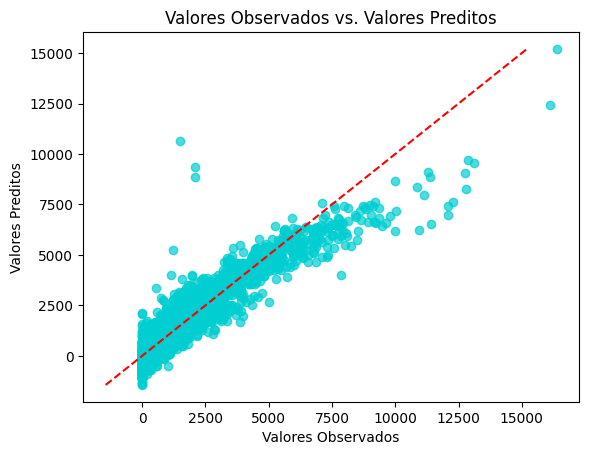

In [44]:
plt.scatter(y,
            y_hat,
            color="darkturquoise",
            alpha=0.7)
plt.plot([y_hat.min(), y_hat.max()], [y_hat.min(), y_hat.max()], color='red', linestyle='--')
plt.title("Valores Observados vs. Valores Preditos")
plt.xlabel("Valores Observados")
plt.ylabel("Valores Preditos")
plt.show()

### **Etapa 5: Análise de observações influentes**

*Cálculo das distâncias de Cook*

In [45]:
influencias = sm.OLS(y, sm.add_constant(X_tratada_2)).fit().get_influence()
dist_cook = influencias.cooks_distance[0]

*Especificação de limite para identificação de pontos influentes*

In [46]:
# Limite padrão (4/n)
limite = 4/dados.shape[0]

# OU

# Limite personalizado
# limite = ...

*Gráfico das distâncias de Cook*

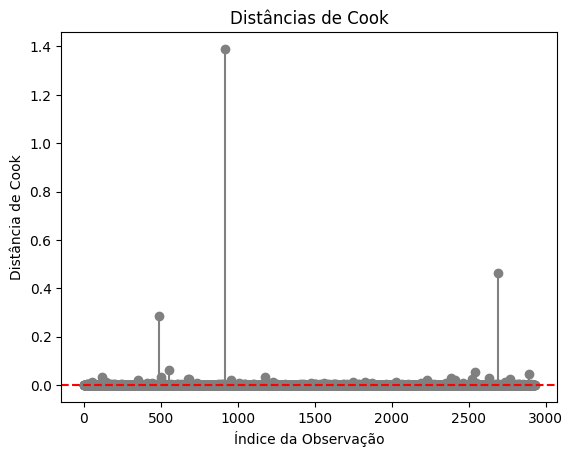

In [47]:
plt.stem(dist_cook,
         markerfmt="o",
         linefmt="gray",
         basefmt=" ")
plt.axhline(limite,
            color='red',
            linestyle='--')
plt.title("Distâncias de Cook")
plt.xlabel("Índice da Observação")
plt.ylabel("Distância de Cook")
plt.show()

Insira seu texto de conclusões aqui

Conclusões:
O histograma de resíduos e o Q-Q plot gerado seguem uma distribuição aproximadamente normal, conforme podemos ver nos gráficos gerados.

O Gráfico de Resíduos vs Valores Preditos mostram um padrão de comportamento específico, uma variabilidade decrescente principalmente na faixa que vai de -1000 até 2500 para valores preditos. Depois dessa faixa o gráfico mostra certa aleatoriedade na distribuição de resíduos.

No gráfico de Valores Observados vs Valores Preditos é possível verificar uma concentração de pontos sobre uma reta de 45 graus, o que representa uma distribuição praticamente normal dos pontos.

No gráfico das distãncias de Cook, podemos verificar que existem 3 pontos que se distanciam mais do limite estabelecido: Com distãncias de Cook aproximadamente igual a 1.4 , 0.3 e 0.5 .

### **QUESTÃO 6**

6. (1 ponto) Divida a base de dados original em conjuntos de treino (75%) e teste externo (25%), usando a semente aleatória 123. Considerando todas as variáveis explicativas disponíveis, desenvolva o pré-processamento no conjunto de treino:

para variáveis qualitativas, transforme-as utilizando codificação one-hot; 

e para variáveis quantitativas, padronize as escalas utilizando o método z-score. 

Aplique as transformações no conjunto de teste externo. Por quais motivos esses dois tipos de tratamentos são necessários?

In [48]:
# Insira seus códigos em Python aqui (divida em várias células, se desejar)

### **Etapa 2: Divisão de treino e teste externo**

In [49]:
X_treino, X_teste, y_treino, y_teste = train_test_split(X, y,
                                                        test_size=0.25,
                                                        random_state=123)

### **Etapa 3: Pré-processamento de variáveis explicativas**

*Definição das funções de pré-processamento: Padronização das variáveis quantitativas + Codificação one-hot para variáveis qualitativas*

In [50]:
preprocessador = ColumnTransformer(transformers=[
    ("quanti", StandardScaler(), lista_X_quanti),
    ("quali", OneHotEncoder(sparse_output=False, drop="first", handle_unknown='ignore'), lista_X_quali)
])

*Criação do pré-processamento no conjunto de treino* <br>

In [51]:
X_treino_tratada = preprocessador.fit_transform(X_treino)  # O pré-processamento não deve envolver o conjunto de teste externo, que deve ficar reservado apenas para aplicações de resultados já obtidos, e nunca construções
if lista_X_quali:
    nomes_quali = list(preprocessador.named_transformers_['quali'].get_feature_names_out(lista_X_quali))
else:
    nomes_quali = []
nomes_variaveis = list(lista_X_quanti) + nomes_quali

In [52]:
X_treino_tratada = pd.DataFrame(X_treino_tratada, columns=nomes_variaveis)
X_treino_tratada.head()

,IDADE_CLIENTE,RENDA_MENSAL_CLIENTE,BEHAVIOUR_SCORE_CLIENTE,QTD_TRANSACOES_3M,QTD_ITENS_3M,VALOR_GASTO_3M,TICKET_MEDIO_3M,FLAG_ALTO_CUSTO_3M_1,SATISFACAO_CARTAO_02_Satisfeito,SATISFACAO_CARTAO_03_Neutro,SATISFACAO_CARTAO_04_Insatisfeito,SATISFACAO_CARTAO_05_Muito_Insatisfeito,SATISFACAO_CARTAO_Nao_Respondeu
0,-0.184561,-0.958034,-3.211291,-0.670852,-0.739720,0.472931,1.075033,0.0,1.0,0.0,0.0,0.0,0.0
1,1.918628,-0.852028,1.335623,1.662130,1.704872,0.631318,-0.749642,1.0,0.0,1.0,0.0,0.0,0.0
2,0.975819,-0.958034,1.268757,1.078885,1.215954,-0.015917,-0.826792,1.0,0.0,0.0,0.0,0.0,1.0
3,-0.692227,-0.958034,-2.943825,-1.254097,-1.228639,-0.121509,2.626818,0.0,0.0,0.0,1.0,0.0,0.0
4,1.048343,1.438138,0.533227,1.078885,0.727035,1.622703,-0.126713,0.0,0.0,0.0,0.0,0.0,1.0


*Aplicação do pré-processamento no conjunto de teste externo*

In [53]:
X_teste_tratada = preprocessador.fit_transform(X_teste)  # Note que o mesmo objeto de pré-processamento deve ser utilizado, agora com 'transform' em vez de 'fit_transform'
X_teste_tratada = pd.DataFrame(X_teste_tratada, columns=nomes_variaveis)
X_teste_tratada.head()

,IDADE_CLIENTE,RENDA_MENSAL_CLIENTE,BEHAVIOUR_SCORE_CLIENTE,QTD_TRANSACOES_3M,QTD_ITENS_3M,VALOR_GASTO_3M,TICKET_MEDIO_3M,FLAG_ALTO_CUSTO_3M_1,SATISFACAO_CARTAO_02_Satisfeito,SATISFACAO_CARTAO_03_Neutro,SATISFACAO_CARTAO_04_Insatisfeito,SATISFACAO_CARTAO_05_Muito_Insatisfeito,SATISFACAO_CARTAO_Nao_Respondeu
0,-0.726791,0.310178,-0.054599,-0.707280,-0.282074,-1.222582,-0.671901,0.0,1.0,0.0,0.0,0.0,0.0
1,0.928121,1.311296,0.641416,1.782210,0.789222,2.315466,-0.174934,0.0,0.0,0.0,0.0,0.0,1.0
2,1.143979,1.417650,1.476633,1.159837,1.324870,0.128870,-0.774919,1.0,0.0,1.0,0.0,0.0,0.0
3,-0.654838,0.326362,0.711017,-0.084908,-0.282074,0.554670,0.205409,0.0,0.0,1.0,0.0,0.0,0.0
4,-1.014602,-0.136048,-1.377026,1.159837,-0.817722,0.036305,-0.814040,0.0,0.0,0.0,0.0,0.0,0.0


Insira seu texto de conclusões 

Conclusões:
O Z-Score é usado para padronizar a escala das variáveis. Essa padronização é necessária pois variáveis em escalas diferentes impactam os coeficientes de forma diferente.
Já o método OneHotEncoder é usado para evitar colinearidade em variáveis qualitativas, pois uma das dummies criadas pode ser descartada pois é totalmente correlacionada com a combinação das demais.

### **QUESTÃO 7**

In [54]:
# Insira seus códigos em Python aqui (divida em várias células, se desejar)

### **Etapa 4: Definição dos algoritmos e intervalos de busca de hiperparâmetros**

In [55]:
algoritmos = {

    'REGRESSÃO LINEAR + RIDGE': (Ridge(), {
        'alpha': loguniform(1e-5, 1e1)                # Peso da penalização
    }),

    'REGRESSÃO LINEAR + LASSO': (Lasso(random_state=123, max_iter=500), {
        'alpha': loguniform(1e-5, 1e1)                # Peso da penalização
    }),

    'REGRESSÃO LINEAR + ELASTICNET': (ElasticNet(random_state=123, max_iter=500), {
        'alpha': loguniform(1e-5, 1e1),               # Peso da penalização
        'l1_ratio': uniform(0, 1),                    # Contribuição da penalização LASSO (L1) em relação a Ridge (L2)
    }),

   # 'REGRESSÃO LINEAR VIA GRADIENTE DESCENDENTE': (SGDRegressor(random_state=123, max_iter=500, tol=1e-3), {
   #     'penalty': ['l2', 'l1', 'elasticnet'],
   #     'alpha': loguniform(1e-5, 1e1),               # Peso da penalização
   #     'l1_ratio': uniform(0, 1),                    # Contribuição da penalização LASSO (L1) em relação a Ridge (L2)
   #     'eta0': loguniform(1e-4, 1e-1),               # Taxa de aprendizado inicial
   #     'learning_rate': ['constant',                 # Atualização de eta0: manter sempre constante
   #                       'invscaling',               # Atualização de eta0: reduzir gradativamente ao longo das iterações
   #                       'adaptive']                 # Atualização de eta0: reduzir gradativamente ao longo das iterações, se não houver redução do erro
   # }),

    'ÁRVORE DE REGRESSÃO': (DecisionTreeRegressor(random_state=123), {
        'min_impurity_decrease': uniform(0, 0.05),    # Percentual mínimo de redução de impureza
        'min_samples_split': randint(100, 200),       # Qtde. mínima de observações no nó "pai" (ATENÇÃO: depende do tamanho da base)
        'min_samples_leaf': randint(50, 100),         # Qtde. mínima de observações no nó "filho" (ATENÇÃO: depende do tamanho da base)
        'max_depth': randint(2, 8),                  # Profundidade máxima da árvore
    }),

    'FLORESTA ALEATÓRIA': (RandomForestRegressor(random_state=123, n_jobs = -1), {
        'n_estimators': randint(10, 500),             # Qtde. de árvores na floresta
        'min_impurity_decrease': uniform(0, 0.05),    # Percentual mínimo de redução de impureza
        'min_samples_split': randint(100, 200),       # Qtde. mínima de observações no nó "pai" (ATENÇÃO: depende do tamanho da base)
        'min_samples_leaf': randint(50, 100),         # Qtde. mínima de observações no nó "filho" (ATENÇÃO: depende do tamanho da base)
        'max_samples': uniform(0.6, 0.4),             # Percentual de observações consideradas em cada árvore
        'max_features': ['sqrt', 'log2', None],       # Qtde. de variáveis consideradas em cada árvore ['sqrt', 'log2', None]
        'max_depth': randint(2, 8)                    # Profundidade máxima das árvores
    }),

    'ADABOOST': (AdaBoostRegressor(random_state=123), {
        'n_estimators': randint(10, 500),             # Qtde. de árvores no boosting
        'learning_rate': loguniform(1e-4, 1e-1)       # Taxa de aprendizado
    }),

    'GRADIENT BOOSTING': (GradientBoostingRegressor(random_state=123), {
        'n_estimators': randint(10, 500),             # Qtde. de árvores no boosting
        'min_impurity_decrease': uniform(0, 0.05),    # Percentual mínimo de redução de impureza
        'learning_rate': loguniform(1e-4, 1e-1),      # Taxa de aprendizado
        'min_samples_split': randint(100, 200),       # Qtde. mínima de observações no nó "pai" (ATENÇÃO: depende do tamanho da base)
        'min_samples_leaf': randint(50, 100),         # Qtde. mínima de observações no nó "filho" (ATENÇÃO: depende do tamanho da base)
        'subsample': uniform(0.6, 0.4),               # Percentual de observações consideradas em cada árvore
        'max_features': ['sqrt', 'log2', None],       # Qtde. de variáveis consideradas em cada árvore ['sqrt', 'log2', None]
        'max_depth': randint(2, 8)                    # Profundidade máxima das árvores
    }),

    'GRADIENT BOOSTING COM HISTOGRAMAS': (HistGradientBoostingRegressor(random_state=123), {
        'max_iter': randint(10, 500),                 # Qtde. de árvores no boosting
        'learning_rate': loguniform(1e-4, 1e-1),      # Taxa de aprendizado
        'min_samples_leaf': randint(50, 100),         # Qtde. mínima de observações no nó "filho" (ATENÇÃO: depende do tamanho da base)
        'max_leaf_nodes': randint(10, 20),            # Qtde. máxima de nós finais (ATENÇÃO: depende do tamanho da base)
        'max_bins': randint(10, 255),                 # Qtde. máxima de bins para discretização
        'l2_regularization': loguniform(1e-5, 1e2),   # Contribuição da penalização Ridge (L2)
        'max_depth': randint(2, 8)                   # Profundidade máxima das árvores
    }),

    'XGBOOST': (XGBRegressor(random_state=123, n_jobs=-1), {
        'n_estimators': randint(10, 500),             # Qtde. de árvores no boosting
        'learning_rate': loguniform(1e-4, 1e-1),      # Taxa de aprendizado
        'colsample_bytree': uniform(0.5, 0.5),        # Percentual de variáveis consideradas em cada árvore
        'subsample': uniform(0.6, 0.4),               # Percentual de observações consideradas em cada árvore
        'gamma': uniform(0, 5),                       # Redução mínima na função de perda para realizar uma quebra
        'reg_alpha': loguniform(1e-5, 1e2),           # Contribuição da penalização LASSO (L1)
        'reg_lambda': loguniform(1e-5, 1e2),          # Contribuição da penalização Ridge (L2)
        'max_depth': randint(2, 8)                   # Profundidade máxima das árvores
    }),

    'LIGHTGBM': (LGBMRegressor(random_state=123, n_jobs=-1, verbosity=-1), {
        'n_estimators': randint(10, 500),             # Qtde. de árvores no boosting
        'learning_rate': loguniform(1e-4, 1e-1),      # Taxa de aprendizado
        'min_child_samples': randint(50, 100),        # Qtde. mínima de observações no nó "filho" (ATENÇÃO: depende do tamanho da base)
        'num_leaves': randint(10, 20),                # Qtde. máxima de nós finais (ATENÇÃO: depende do tamanho da base)
        'subsample': uniform(0.6, 0.4),               # Percentual de observações consideradas em cada árvore
        'reg_alpha': loguniform(1e-5, 1e2),           # Contribuição da penalização LASSO (L1)
        'reg_lambda': loguniform(1e-5, 1e2),          # Contribuição da penalização Ridge (L2)
        'max_depth': randint(2, 8)                   # Profundidade máxima das árvores
    })
    
}

### **Etapa 5: Construção de modelos usando validação cruzada, busca aleatória e teste externo**

*Estratégia de validação cruzada (k-fold) e quantidade máxima de iterações de busca*

In [56]:
kf = KFold(n_splits=10, shuffle=True, random_state=123)
qtd_iteracoes = 50

*Construção dos modelos*

In [57]:
resultados = []         # Lista para armazenar resultados
contador_modelos = 0    # Contador de modelos testados

for nome_algoritmo, (classe_algoritmo, hiperparametros) in algoritmos.items():

    # Início da contagem de tempo e de modelos
    inicio = time.time()

    # Busca aleatória de hiperparâmetros com validação cruzada (randomized search)
    busca = RandomizedSearchCV(
        estimator=classe_algoritmo,
        param_distributions=hiperparametros,
        n_iter=1 if not hiperparametros else qtd_iteracoes,
        scoring='neg_root_mean_squared_error',
        cv=kf,
        return_train_score=True,
        random_state=123,
        n_jobs=-1
    )

    # Ajuste dos modelos
    busca.fit(X_treino_tratada, y_treino)

    # Armazenar os resultados da busca
    resultados_aux = pd.DataFrame({
        "num_modelo": [f"Modelo {contador_modelos + i}" for i in range(len(busca.cv_results_["params"]))],
        "nome_algoritmo": nome_algoritmo,
        "classe_algoritmo": type(classe_algoritmo).__name__,
        "hiperparametros": busca.cv_results_["params"],
        "media_erro_treino": -busca.cv_results_["mean_train_score"],
        "media_erro_teste_interno": -busca.cv_results_["mean_test_score"],
        "dp_erro_treino": busca.cv_results_["std_train_score"],
        "dp_erro_teste_interno": busca.cv_results_["std_test_score"]
    })

    # Calcular erro no teste externo, para cada modelo
    erro_teste = []
    for params in resultados_aux["hiperparametros"]:
        estimador = clone(classe_algoritmo).set_params(**params)
        estimador.fit(X_treino_tratada, y_treino)
        y_hat_teste = estimador.predict(X_teste_tratada)
        erro = root_mean_squared_error(y_teste, y_hat_teste)
        erro_teste.append(erro)

    # Adicionar coluna de erro em teste externo e colunas de variações absolutas de erro em relação ao treino
    resultados_aux["erro_teste_externo"] = erro_teste
    resultados_aux["var_abs_media_erro_teste_interno"] = abs(resultados_aux["media_erro_teste_interno"] - resultados_aux["media_erro_treino"])
    resultados_aux["var_abs_perc_media_erro_teste_interno"] = resultados_aux["var_abs_media_erro_teste_interno"] / resultados_aux["media_erro_treino"]
    resultados_aux["var_abs_erro_teste_externo"] = abs(resultados_aux["erro_teste_externo"] - resultados_aux["media_erro_treino"])
    resultados_aux["var_abs_perc_erro_teste_externo"] = resultados_aux["var_abs_erro_teste_externo"] / resultados_aux["media_erro_treino"]

    resultados.append(resultados_aux)
    contador_modelos += len(resultados_aux)

    # Fim da contagem de tempo e mensagem de finalização
    fim = time.time()
    print(f"({math.ceil(contador_modelos/qtd_iteracoes)} de {len(algoritmos)}) Processo concluído para o algoritmo {nome_algoritmo} em {fim - inicio:.1f} segundos!")

# Criação de data frame com os resultados
resultados = pd.concat(resultados, ignore_index=True)

(1 de 10) Processo concluído para o algoritmo REGRESSÃO LINEAR + RIDGE em 15.2 segundos!
(2 de 10) Processo concluído para o algoritmo REGRESSÃO LINEAR + LASSO em 2.1 segundos!
(3 de 10) Processo concluído para o algoritmo REGRESSÃO LINEAR + ELASTICNET em 1.7 segundos!
(4 de 10) Processo concluído para o algoritmo ÁRVORE DE REGRESSÃO em 2.7 segundos!
(5 de 10) Processo concluído para o algoritmo FLORESTA ALEATÓRIA em 117.9 segundos!
(6 de 10) Processo concluído para o algoritmo ADABOOST em 241.2 segundos!
(7 de 10) Processo concluído para o algoritmo GRADIENT BOOSTING em 139.4 segundos!
(8 de 10) Processo concluído para o algoritmo GRADIENT BOOSTING COM HISTOGRAMAS em 64.4 segundos!
(9 de 10) Processo concluído para o algoritmo XGBOOST em 63.6 segundos!
(10 de 10) Processo concluído para o algoritmo LIGHTGBM em 89.9 segundos!


### **Etapa 6: Comparação de modelos**

*Gráficos de resumo dos algoritmos*

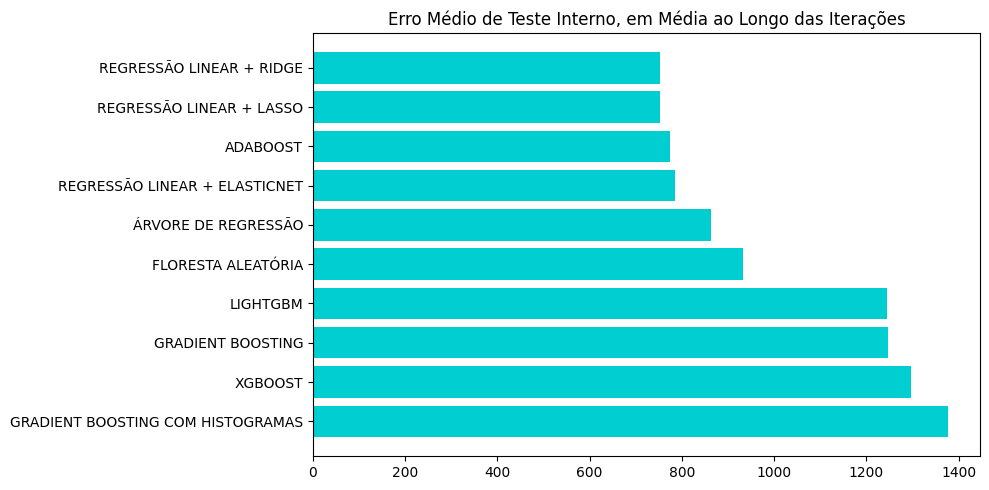

In [58]:
# Gráfico do erro médio nos conjuntos de teste interno, em média ao longo das iterações do randomized search
resumo_algoritmos = (
    resultados
    .groupby("nome_algoritmo")["media_erro_teste_interno"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 5))
plt.barh(resumo_algoritmos.index, resumo_algoritmos.values, color="darkturquoise")
plt.title("Erro Médio de Teste Interno, em Média ao Longo das Iterações")
plt.tight_layout()
plt.show()

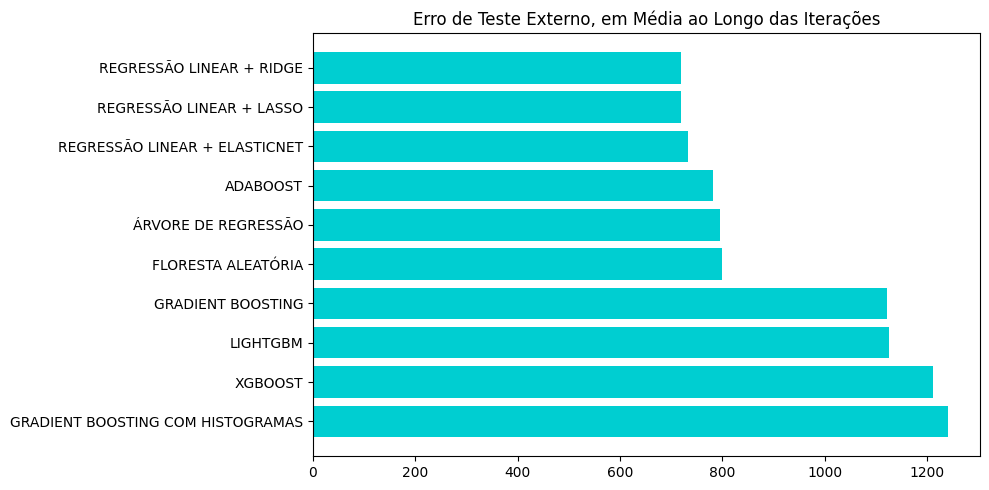

In [59]:
# Gráfico do erro no conjunto de teste externo, em média ao longo das iterações do randomized search
resumo_algoritmos = (
    resultados
    .groupby("nome_algoritmo")["erro_teste_externo"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 5))
plt.barh(resumo_algoritmos.index, resumo_algoritmos.values, color="darkturquoise")
plt.title("Erro de Teste Externo, em Média ao Longo das Iterações")
plt.tight_layout()
plt.show()

*Ordenação e filtragem dos melhores modelos*

In [60]:
# Escolha por qual coluna ordenar
ordenar_por = "media_erro_teste_interno"
# ordenar_por = "var_abs_media_erro_teste_interno"
# ordenar_por = "var_abs_erro_teste_externo"

# Escolha quais o percentuais máximos de variação de erro (da média do treino para a média do teste interno; e da média do treino para o teste externo)
max_var_perc_erro_teste_interno = 0.1  # ex.: 0.1 representa 10%
max_var_perc_erro_teste_externo = 0.1

# Ordenação e filtragem
resultados_filt_ord = resultados[(resultados['var_abs_perc_media_erro_teste_interno'] < max_var_perc_erro_teste_interno) & (resultados['var_abs_perc_erro_teste_externo'] < max_var_perc_erro_teste_externo)]
resultados_filt_ord = resultados_filt_ord.sort_values(ordenar_por, ascending=True)

*Exibição dos melhores modelos, em formato de tabela e gráfico*

In [61]:
pd.set_option('display.float_format', '{:.3f}'.format)   # Quantidade de casas decimais
resultados_filt_ord[['num_modelo',
                     'nome_algoritmo',
                     'hiperparametros',                     
                     'media_erro_treino',
                     'dp_erro_treino',
                     'media_erro_teste_interno',
                     'dp_erro_teste_interno',
                     'var_abs_media_erro_teste_interno',
                     'var_abs_perc_media_erro_teste_interno',
                     'erro_teste_externo',
                     'var_abs_erro_teste_externo',
                     'var_abs_perc_erro_teste_externo']].head(10)   # Escolha quantos modelos quer exibir

,num_modelo,nome_algoritmo,hiperparametros,media_erro_treino,dp_erro_treino,media_erro_teste_interno,dp_erro_teste_interno,var_abs_media_erro_teste_interno,var_abs_perc_media_erro_teste_interno,erro_teste_externo,var_abs_erro_teste_externo,var_abs_perc_erro_teste_externo
306,Modelo 306,GRADIENT BOOSTING,"{'learning_rate': 0.04673014179480298, 'max_de...",579.670,9.036,634.616,113.589,54.946,0.095,620.104,40.433,0.070
494,Modelo 494,LIGHTGBM,"{'learning_rate': 0.03148825485902, 'max_depth...",582.220,10.844,639.470,106.923,57.250,0.098,612.544,30.324,0.052
352,Modelo 352,GRADIENT BOOSTING COM HISTOGRAMAS,"{'l2_regularization': 0.002524911224859439, 'l...",586.207,12.749,641.266,113.517,55.060,0.094,622.494,36.287,0.062
392,Modelo 392,GRADIENT BOOSTING COM HISTOGRAMAS,"{'l2_regularization': 2.3807016406970794e-05, ...",618.096,10.870,650.339,117.798,32.243,0.052,629.834,11.738,0.019
472,Modelo 472,LIGHTGBM,"{'learning_rate': 0.018221241843911416, 'max_d...",617.438,11.796,651.966,113.898,34.527,0.056,631.658,14.220,0.023
387,Modelo 387,GRADIENT BOOSTING COM HISTOGRAMAS,"{'l2_regularization': 0.0002771214177043036, '...",609.343,12.199,655.102,125.055,45.759,0.075,616.497,7.154,0.012
376,Modelo 376,GRADIENT BOOSTING COM HISTOGRAMAS,"{'l2_regularization': 11.509360890386281, 'lea...",613.858,12.984,665.139,123.790,51.281,0.084,668.187,54.329,0.089
473,Modelo 473,LIGHTGBM,"{'learning_rate': 0.027109244279514107, 'max_d...",615.357,12.766,665.848,127.202,50.491,0.082,636.451,21.094,0.034
360,Modelo 360,GRADIENT BOOSTING COM HISTOGRAMAS,"{'l2_regularization': 0.02324046940849038, 'le...",627.075,11.632,671.539,132.021,44.464,0.071,639.398,12.323,0.020
322,Modelo 322,GRADIENT BOOSTING,"{'learning_rate': 0.03010338844193861, 'max_de...",623.773,12.920,673.849,129.400,50.075,0.080,642.867,19.093,0.031


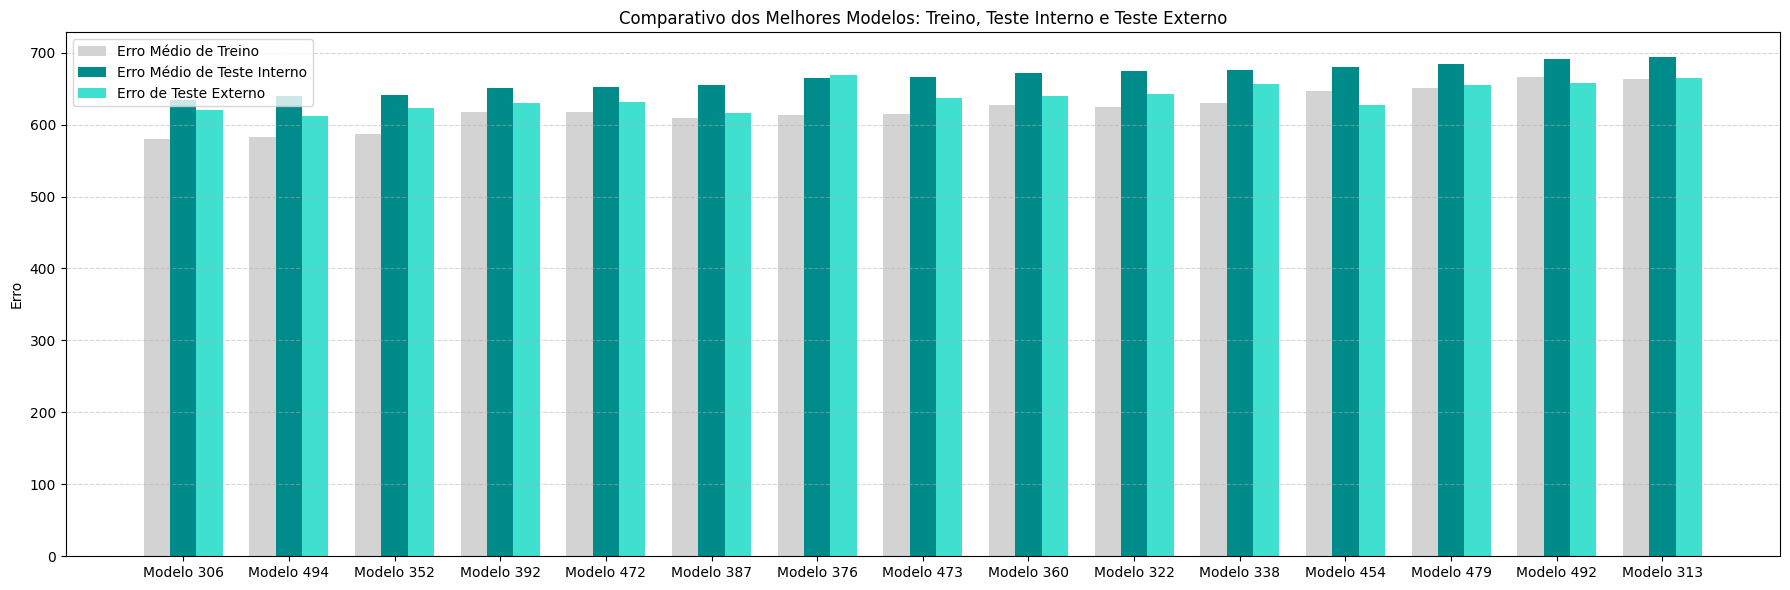

In [62]:
dados_grafico = resultados_filt_ord.head(15)    # Escolha quantos modelos quer exibir
x_pos = np.arange(len(dados_grafico))           # Posições dos rótulos do eixo X
largura_barra = 0.25                            # Largura das barras

plt.figure(figsize=(18, 6))
plt.bar(x_pos - largura_barra,                  # Série com erro médio de treino
        dados_grafico["media_erro_treino"],
        width=largura_barra,
        label="Erro Médio de Treino",
        color="lightgray")
plt.bar(x_pos,                                  # Série com erro médio de teste interno
        dados_grafico["media_erro_teste_interno"],
        width=largura_barra,
        label="Erro Médio de Teste Interno",
        color="darkcyan")
plt.bar(x_pos + largura_barra,                  # Série com erro médio de teste externo
        dados_grafico["erro_teste_externo"],
        width=largura_barra,
        label="Erro de Teste Externo",
        color="turquoise")

plt.xticks(x_pos,
           dados_grafico["num_modelo"],
           rotation=0,
           ha='center')
plt.ylabel("Erro")
plt.title("Comparativo dos Melhores Modelos: Treino, Teste Interno e Teste Externo")
plt.legend()
plt.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

### **Etapa 7: Escolha do modelo**

*Escolha do modelo*

In [87]:
num_modelo_escolhido = "Modelo 306"   # Substitua aqui o número do modelo escolhido

*Características do modelo escolhido*

In [88]:
linha = resultados.loc[resultados["num_modelo"] == num_modelo_escolhido].squeeze()
nome_algoritmo = linha["nome_algoritmo"]
hiperparametros = linha["hiperparametros"]
classe = algoritmos[nome_algoritmo][0]
print(f"O modelo final adotado foi construído com o algoritmo {nome_algoritmo}, com hiperparâmetros: { {k: round(v, 4) if isinstance(v, float) else v for k, v in hiperparametros.items()} }")

O modelo final adotado foi construído com o algoritmo GRADIENT BOOSTING, com hiperparâmetros: {'learning_rate': np.float64(0.0467), 'max_depth': 5, 'max_features': 'log2', 'min_impurity_decrease': np.float64(0.0347), 'min_samples_leaf': 56, 'min_samples_split': 126, 'n_estimators': 218, 'subsample': np.float64(0.721)}


Insira seu texto de conclusões aqui

Conclusões: O melhor modelo considerando o menor erro no teste interno é o modelo 306, construído com o algoritmo GRADIENT BOOSTING, com os hiperparâmetros:
learning rate: 0,0467
max_depth: 5
max_features: log2
min_impurity_decrease: 0,0347
min_samples_leaf: 56
min_samples_split: 126
n_estimators: 218
subsample: 0,721

Este modelo foi escolhido como melhor pois obteve o menor erro médio de teste interno. O erro no no treino ficou menor que 600 e o erro de teste externo ficou entre o erro no treino e o erro no teste interno. A diferença entre esses três erros é pequena, demonstrando estabilidade do modelo. 

### **QUESTÃO 8**

8. (0,5 ponto) No conjunto de teste externo, calcule o RMSE, MAE, MAPE e R2 do modelo obtido no item (7). Examine, tambem, o comportamento gráfico dos resíduos. Interprete todos os resultados gerados.

In [65]:
# Insira seus códigos em Python aqui (divida em várias células, se desejar)

*Retreino do modelo no conjunto de treino completo*

In [91]:
modelo_final = classe.set_params(**hiperparametros)
modelo_final.fit(X_treino_tratada, y_treino)

,loss,'squared_error'
,learning_rate,np.float64(0....3014179480298)
,n_estimators,218
,subsample,np.float64(0.7210197815814181)
,criterion,'friedman_mse'
,min_samples_split,126
,min_samples_leaf,56
,min_weight_fraction_leaf,0.0
,max_depth,5
,min_impurity_decrease,np.float64(0....7016218012572)
,init,None


### **Etapa 8: Análises adicionais no conjunto de teste externo**

*Aplicação do modelo final no conjunto de teste externo*

In [93]:
y_hat_teste = modelo_final.predict(X_teste_tratada)

*Erro quadrático médio em raiz (RMSE)*

In [94]:
np.sqrt(np.mean((y_teste - y_hat_teste)**2))

np.float64(620.1038000597092)

*Erro absoluto médio (MAE)*

In [95]:
np.mean(np.abs(y_teste - y_hat_teste))

np.float64(400.59192946568)

*Erro absoluto percentual médio (MAPE)*

In [96]:
np.mean(np.abs((y_teste - y_hat_teste) / y))

np.float64(inf)

In [ ]:
# Verificando se existem y iguais a zero. Se houver, não é possível calcular o MAPE.
y[y == 0].head()

5     0
25    0
27    0
31    0
35    0
Name: VALOR_GASTO_PROX_12M, dtype: int64

*Coeficiente de determinação (R²)*

In [98]:
r2_score(y_teste, y_hat_teste)

0.8811848854885632

*Resíduos do modelo (e)*

In [99]:
resid = y_teste - y_hat_teste

*Histograma dos resíduos*

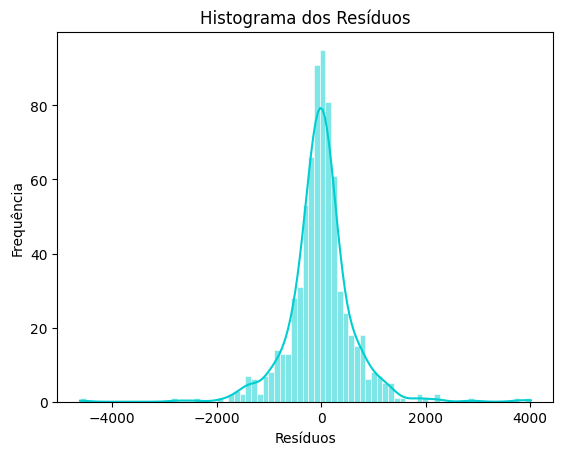

In [100]:
sns.histplot(resid,
             color="darkturquoise",
             edgecolor="white",
             kde=True)
plt.title("Histograma dos Resíduos")
plt.xlabel("Resíduos")
plt.ylabel("Frequência")
plt.show()

*Q-Q plot dos resíduos*

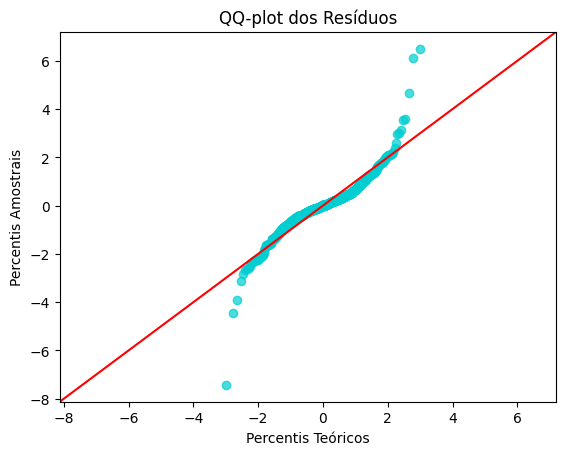

In [101]:
sm.qqplot(resid,
          line='45',
          fit=True,
          markerfacecolor='darkturquoise',
          markeredgecolor='darkturquoise',
          alpha=0.7)
plt.title("QQ-plot dos Resíduos")
plt.xlabel("Percentis Teóricos")
plt.ylabel("Percentis Amostrais")
plt.show()

*Gráfico de resíduos vs. valores preditos*

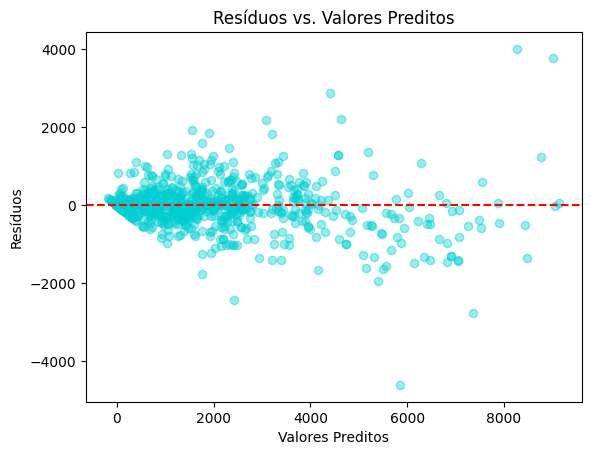

In [102]:
plt.scatter(y_hat_teste,
            resid,
            color="darkturquoise",
            alpha=0.4)
plt.axhline(0, color='red', linestyle='--')
plt.title("Resíduos vs. Valores Preditos")
plt.xlabel("Valores Preditos")
plt.ylabel("Resíduos")
plt.show()

*Gráfico de valores observados vs. valores preditos da resposta*

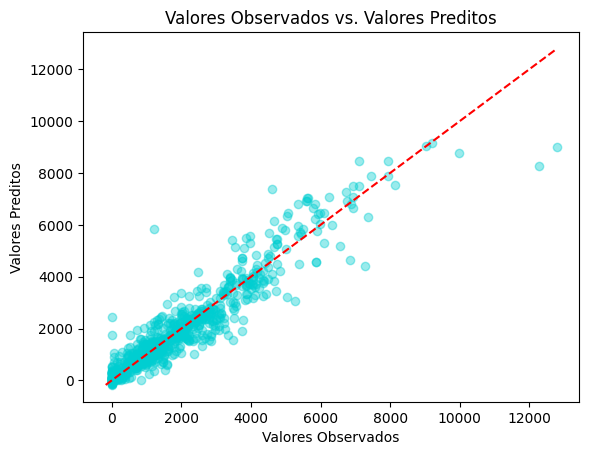

In [103]:
min_eixo = min(y_teste.min(), y_hat_teste.min())
max_eixo = max(y_teste.max(), y_hat_teste.max())
plt.scatter(y_teste,
            y_hat_teste,
            color="darkturquoise",
            alpha=0.4)
plt.plot([min_eixo, max_eixo], [min_eixo, max_eixo], color='red', linestyle='--')
plt.title("Valores Observados vs. Valores Preditos")
plt.xlabel("Valores Observados")
plt.ylabel("Valores Preditos")
plt.show()

Insira seu texto de conclusões aqui

Conclusões:
RMSE = 620,1038
MAE = 400,5919
MAPE = Não foi possível calcular pois existem valores valores observados (y) iguais a zero.
R2 = 0,8812

Sobre os gráficos dos resíduos:

Histograma dos resíduos: Apresenta uma distribuição aproximadamente normal, conforme esperado.

Q-Q Plot dos Resíduos: Apresenta um comportamento de distribuição  aproximadadmente normal, e os percentis amostrais e teóricos se distribuem ao longo de uma reta a 45 graus.

Gráfico de Resíduos vs Valores Preditos: Apresenta um comportamento de variabilidade crescente no intervalo de Valores Preditos entre 0 e 1000 aproximadadmente. Para Valores Preditos mais altos observa-se mais aleatoriedade no pontos.

Gráfico Valores Observados vs Valores Preditos: Os pontos estão distribuídos próximos a uma reta a 45 graus, conforme esperado.

### **QUESTÃO 9**

9. (1 ponto) Avalie o grau de importância das variáveis no modelo obtido no item (7), de acordo com:

• Redução de impureza (caso se trate de um modelo baseado em árvores)
• Permutação
• Valores SHAP

Os métodos apontam para conclusões semelhantes?

In [78]:
# Insira seus códigos em Python aqui (divida em várias células, se desejar)

*Cálculo da importância em redução de impureza para cada variável no modelo final (aplicável apenas para modelos baseados em árvores)*

In [106]:
# ATENÇÃO! Aplicável apenas caso o modelo final seja baseado em árvores; caso contrário, resultará em erro
importancias_impureza = pd.Series(modelo_final.feature_importances_,
                                  index=X_treino_tratada.columns).sort_values()

*Gráfico de importâncias em redução de impureza (aplicável apenas para modelos baseados em árvores)*

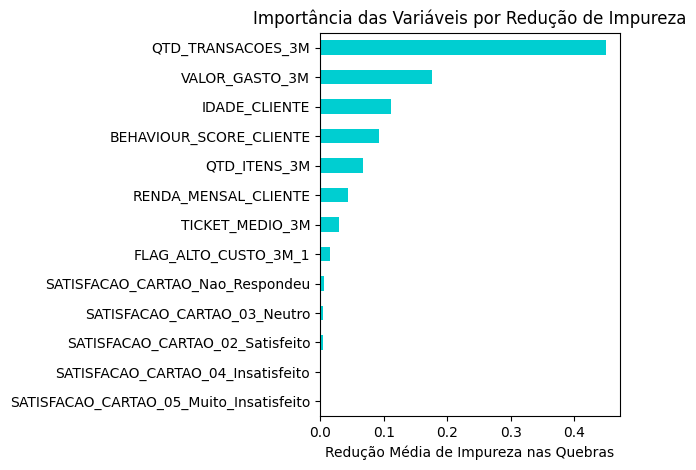

In [113]:
# ATENÇÃO! Aplicável apenas caso o modelo final seja baseado em árvores; caso contrário, resultará em erro
importancias_impureza.plot.barh(title="Importância das Variáveis por Redução de Impureza",
                                  color="darkturquoise")
plt.xlabel("Redução Média de Impureza nas Quebras")
plt.tight_layout()
plt.show()

*Cálculo da importância via permutação para cada variável no modelo final*

In [114]:
importancias_permutacao = permutation_importance(modelo_final,
                                                 X_treino_tratada,
                                                 y_treino,
                                                 n_repeats=30,
                                                 random_state=0, 
                                                 scoring='neg_root_mean_squared_error')
importancias_permutacao = pd.Series(importancias_permutacao.importances_mean,
                                    index=X_treino_tratada.columns).sort_values()

*Gráfico de importâncias por permutação*

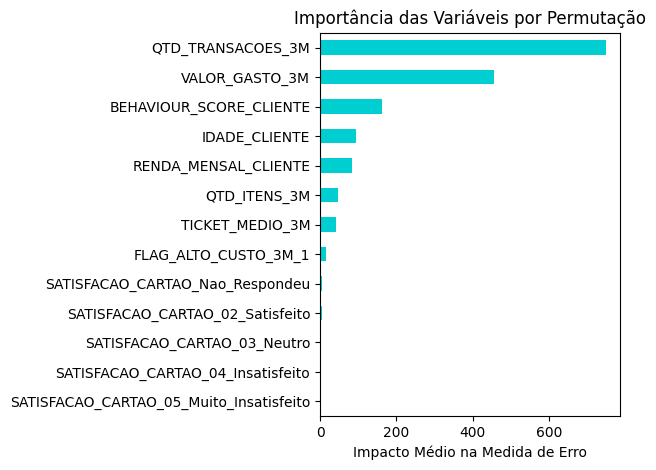

In [115]:
importancias_permutacao.plot.barh(title="Importância das Variáveis por Permutação",
                                  color="darkturquoise")
plt.xlabel("Impacto Médio na Medida de Erro")
plt.tight_layout()
plt.show()

*Cálculo dos valores SHAP das variáveis no modelo final*

In [116]:
if nome_algoritmo not in ['ADABOOST']:
    # Caso demore para rodar, especialmente em bases grandes, substitua X_treino_tratada.shape[0] por um número de tamanho de subamostra (ex.: 100)
    X_amostra = shap.sample(X_treino_tratada, X_treino_tratada.shape[0], random_state=123)
    explainer = shap.Explainer(modelo_final, X_amostra)
    valores_shap = explainer(X_amostra, check_additivity=False)
else:
    # Para AdaBoost, a implementação do cálculo de valores SHAP não é direta; é preciso usar um método mais oneroso computacionalmente, em uma subamostra pequena de observações
    X_amostra = shap.sample(X_treino_tratada, 100, random_state=123)
    explainer = shap.Explainer(modelo_final.predict, X_amostra)
    valores_shap = explainer(X_amostra, check_additivity=False)

*Gráfico de valores absolutos médios de SHAP*

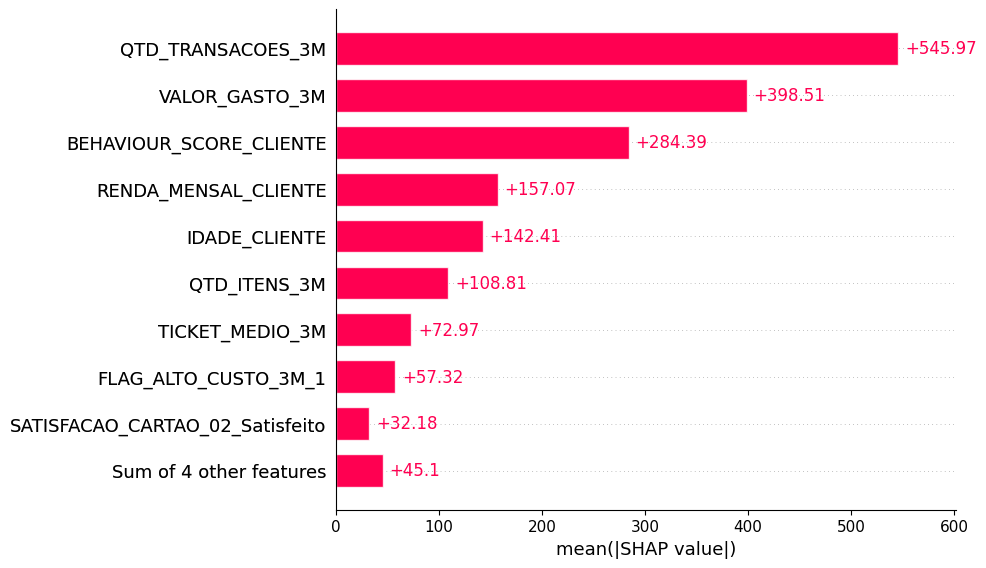

In [117]:
shap.plots.bar(valores_shap)

Insira seu texto de conclusões aqui

Conclusões: 
Segundo o gráfico de Importância de Variáveis por Redução de Impureza, as variáveis mais importantes são nesta ordem:
- QTD_TRANSACOES_3M
- VALOR_GASTO_3M
- IDADE_CLIENTE
- BEHAVIOUR_SCORE_CLIENTE
- QTD_ITENS_3M


Já segundo o gráfico de Importância das Variáveis por Permutação, as variáveis mais importantes são:
- QTD_TRANSACOES_3M
- VALOR_GASTO_3M
- BEHAVIOUR_SCORE_CLIENTE
- IDADE_CLIENTE
- RENDA_MENSAL_CLIENTE

No gráfico de valores absolutos médios de SHAP, as variáveis mais importantes são:
- QTD_TRANSACOES_3M
- VALOR_GASTO_3M
- BEHAVIOUR_SCORE_CLIENTE
- RENDA_MENSAL_CLIENTE
- IDADE_CLIENTE

Portanto, o método de permutação e o SHAP apontam para conclusões bastante semelhantes. O método por Redução de Impureza considera a variável QTD_ITENS_3M entre as cinco variáveis mais importantes mas não considera a RENDA_MENSAL_CLIENTE como faz os outros dois métodos. Em todos os métodos, as variáveis QTD_TRANSACOES_3M e VALOR_GASTO_3M são as mais importantes.

### **QUESTÃO 10**

10. (1 ponto) A partir dos valores SHAP, interprete as direções das relações exercidas pelas cinco principais variáveis explicativas. Elas são coerentes com a análise bivariada e com
a visão de negócio?

In [85]:
# Insira seus códigos em Python aqui (divida em várias células, se desejar)

*Gráfico de direção do impacto baseado em SHAP (beeswarm)*

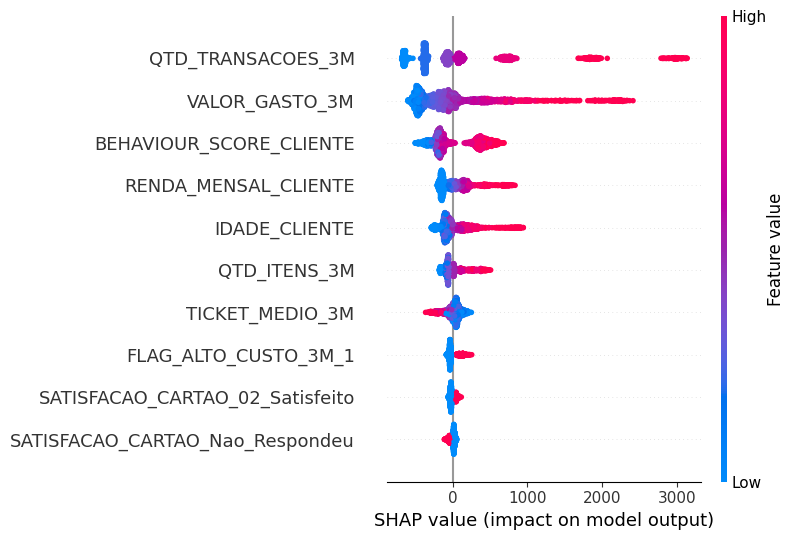

In [118]:
shap.summary_plot(valores_shap, X_amostra, max_display=10)

Insira seu texto de conclusões aqui

Conclusões:
As cinco principais variáveis explicativas segundo os valores SHAP:

- QTD_TRANSACOES_3M
- VALOR_GASTO_3M
- BEHAVIOUR_SCORE_CLIENTE
- RENDA_MENSAL_CLIENTE
- IDADE_CLIENTE

Segundo a análise bivariada, vemos que o valor gasto em 12 meses, em geral, aumenta conforme as variáveis explicativas acima aumentam. Portanto vemos uma relação diretamente proporcional entre o valor gasto em 12 meses e todas essas cinco variáveis. No gráfico de direção do impacto baseado em SHAP, podemos ver também a relação direta entre essas cinco variáveis e a variável resposta. Aparentemente, a relação dessas variáveis com a variável resposta é coerente do ponto de vista de negócio. Quanto maior o valor dessas variáveis, maior o valor gasto em 12 meses.  